# Projet Probabilistic Graphical Model - NOT-MIWAE Vs MIWAE

## Run this if you work on Colab

In [1]:
# Run if destination doesn't already exists
!git clone https://github.com/VincentGefflaut/notMIWAE-project.git

Cloning into 'notMIWAE-project'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 105 (delta 47), reused 45 (delta 25), pack-reused 19 (from 1)
Receiving objects: 100% (105/105), 1.94 MiB | 6.29 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [2]:
# Always run before working in Colab
import sys
sys.path.insert(0,'/content/notMIWAE-project')
!cd notMIWAE-project; git pull

Already up to date.


In [3]:
# Add path_prefix before all paths
path_prefix = '/content/notMIWAE-project/'

## Core

In [6]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
# tf.disable_eager_execution() # Déjà géré par notre patch sed, mais sécurité
import os
import sys
import matplotlib.pyplot as plt

# Imports du repo local
from MIWAE import MIWAE
from notMIWAE import notMIWAE
import trainer
import utils

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Fonctions de chargement et préparation ---

def load_uci_data(dataset_name):
    """Charge les datasets via les URLs UCI."""
    print(f"Chargement de {dataset_name}...")
    if dataset_name == 'White':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Red':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Banknote':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
        data = pd.read_csv(url, header=None).values
    elif dataset_name == 'Concrete':
        # Concrete nécessite souvent openpyxl
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
        try:
            data = pd.read_excel(url).values
        except:
            print("Erreur chargement Excel Concrete. Installation dépendance...")
            os.system('pip install xlrd')
            data = pd.read_excel(url).values
    else:
        raise ValueError("Dataset non supporté dans ce script demo.")
    return data

def introduce_mnar_missing(X, missing_mechanism = lambda x: x > np.mean(x), missing_col_ratio=0.5):
    """
    Simule le mécanisme MNAR (Self-masking) décrit dans l'article.
    Le mécanisme de masquage correspond à la fonction missing_mechanism passée en argument.
    Par défaut, si la valeur > moyenne de la colonne, elle devient manquante.
    Appliqué sur les 100*missing_col_ratio pourcent premières colonnes.
    """
    N, D = X.shape
    Xnan = X.copy()
    n_missing_cols = int(D * missing_col_ratio)

    for j in range(n_missing_cols):
        col = Xnan[:, j]
        mask_condition = missing_mechanism(col)
        Xnan[mask_condition, j] = np.nan
    # Version avec 0 à la place des NaN (pour l'input réseau)
    Xz = Xnan.copy()
    Xz[np.isnan(Xnan)] = 0

    return Xnan, Xz

In [ ]:
# --- Paramètres de l'expérience (Tableau 1) ---

# Pour tester rapidement que tout marche, on réduit les itérations.
# Pour le VRAI résultat, mettez max_iter = 50000 ou 100000
MAX_ITER = 50000
BATCH_SIZE = 16
N_SAMPLES = 20
L_IMP = 500 # Échantillons pour l'imputation finale

# Validation split
VAL_SPLIT = 0.2  # 20% for validation

# Liste des datasets à tester (Commencez par 'White' pour tester)
DATASETS = ['White', 'Banknote']

# Liste des modèles
MODELS = ['MIWAE', 'notMIWAE_selfmasking']

results = []
loss_histories = {}  # Store loss histories for plotting

for dataset in DATASETS:
    # 1. Préparation Données
    data = load_uci_data(dataset)
    # On enlève la dernière colonne (target/class) comme dans task01.py
    data = data[:, :-1]

    N, D = data.shape
    dl = D - 1 # Dimension latente

    # Standardisation (Centrer-Réduire)
    scaler = StandardScaler()
    data = scaler.fit_transform(data)

    # Shuffle
    np.random.seed(42)
    p = np.random.permutation(N)
    data = data[p, :]

    # Train/Val split BEFORE introducing missing data
    data_train, data_val = train_test_split(data, test_size=VAL_SPLIT, random_state=42, shuffle=True)

    print(f"Dataset split: {len(data_train)} train, {len(data_val)} val")

    # Création des manques pour TRAIN
    Xnan_train, Xz_train = introduce_mnar_missing(data_train)
    S_train = np.array(~np.isnan(Xnan_train), dtype=np.float32)

    # Création des manques pour VAL (même mécanisme, mais patterns différents!)
    Xnan_val, Xz_val = introduce_mnar_missing(data_val)
    S_val = np.array(~np.isnan(Xnan_val), dtype=np.float32)

    # 2. Entrainement des modèles
    for model_name in MODELS:
        tf.reset_default_graph() # Nettoyage mémoire TF
        sess_name = f"/tmp/{dataset}_{model_name}"

        print(f"\n--- Dataset: {dataset} | Modèle: {model_name} ---")

        if model_name == 'MIWAE':
            model = MIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                            n_hidden=128, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)

            # Calcul RMSE sur TRAIN (pour voir l'overfitting)
            rmse_train = utils.imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]

            # Calcul RMSE sur VAL (la vraie métrique de généralisation!)
            rmse_val = utils.imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        elif 'notMIWAE' in model_name:
            # Choix du processus (linear=agnostic, selfmasking, etc.)
            proc = 'linear' if 'agnostic' in model_name else 'selfmasking'
            if 'known' in model_name: proc = 'selfmasking_known'

            model = notMIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                                n_hidden=128, missing_process=proc, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)

            # Calcul RMSE sur TRAIN
            rmse_train = utils.not_imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]

            # Calcul RMSE sur VAL
            rmse_val = utils.not_imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        # Store loss history for plotting
        loss_histories[f"{dataset}_{model_name}"] = history

        print(f"\nRésultats RMSE:")
        print(f"  Train RMSE: {rmse_train:.4f} (données d'entraînement)")
        print(f"  Val RMSE:   {rmse_val:.4f} (données de validation - vraie métrique!)")
        print(f"  Generalization gap: {rmse_val - rmse_train:.4f}")

        # Store both metrics
        results.append({
            'Dataset': dataset,
            'Model': model_name,
            'RMSE_train': rmse_train,
            'RMSE_val': rmse_val,
            'Gap': rmse_val - rmse_train
        })

print("\n" + "="*80)
print("=== RÉSULTATS FINAUX ===")
print("="*80)
df = pd.DataFrame(results)
print("\nTableau complet:")
print(df.to_string(index=False))

print("\n" + "-"*80)
print("Interprétation:")
print("-"*80)
print("- RMSE_train: Performance sur les données d'entraînement")
print("- RMSE_val:   Performance sur les données de validation")
print("- Gap:        Différence = mesure de l'overfitting")
print("="*80)


Chargement de White...
Dataset split: 3918 train, 980 val

--- Dataset: White | Modèle: MIWAE ---
Creating graph...
Saving session...
Saving session...
0/50000 updates, 4.14 s, 13.05 train_loss, 12.80 val_loss
Saving session...
100/50000 updates, 0.46 s, 9.62 train_loss, 9.03 val_loss
Saving session...
200/50000 updates, 0.35 s, 8.80 train_loss, 8.59 val_loss
300/50000 updates, 0.37 s, 8.98 train_loss, 8.94 val_loss
Saving session...
400/50000 updates, 0.32 s, 8.94 train_loss, 8.56 val_loss
Saving session...
500/50000 updates, 0.35 s, 9.11 train_loss, 8.48 val_loss
Saving session...
600/50000 updates, 0.38 s, 8.97 train_loss, 8.42 val_loss
700/50000 updates, 0.35 s, 8.36 train_loss, 8.45 val_loss
800/50000 updates, 0.33 s, 9.27 train_loss, 8.47 val_loss
Saving session...
900/50000 updates, 0.34 s, 8.11 train_loss, 8.38 val_loss
Saving session...
1000/50000 updates, 0.35 s, 9.27 train_loss, 8.34 val_loss
1100/50000 updates, 0.35 s, 10.43 train_loss, 8.47 val_loss
1200/50000 updates, 0.3

## Training metrics
### Plots

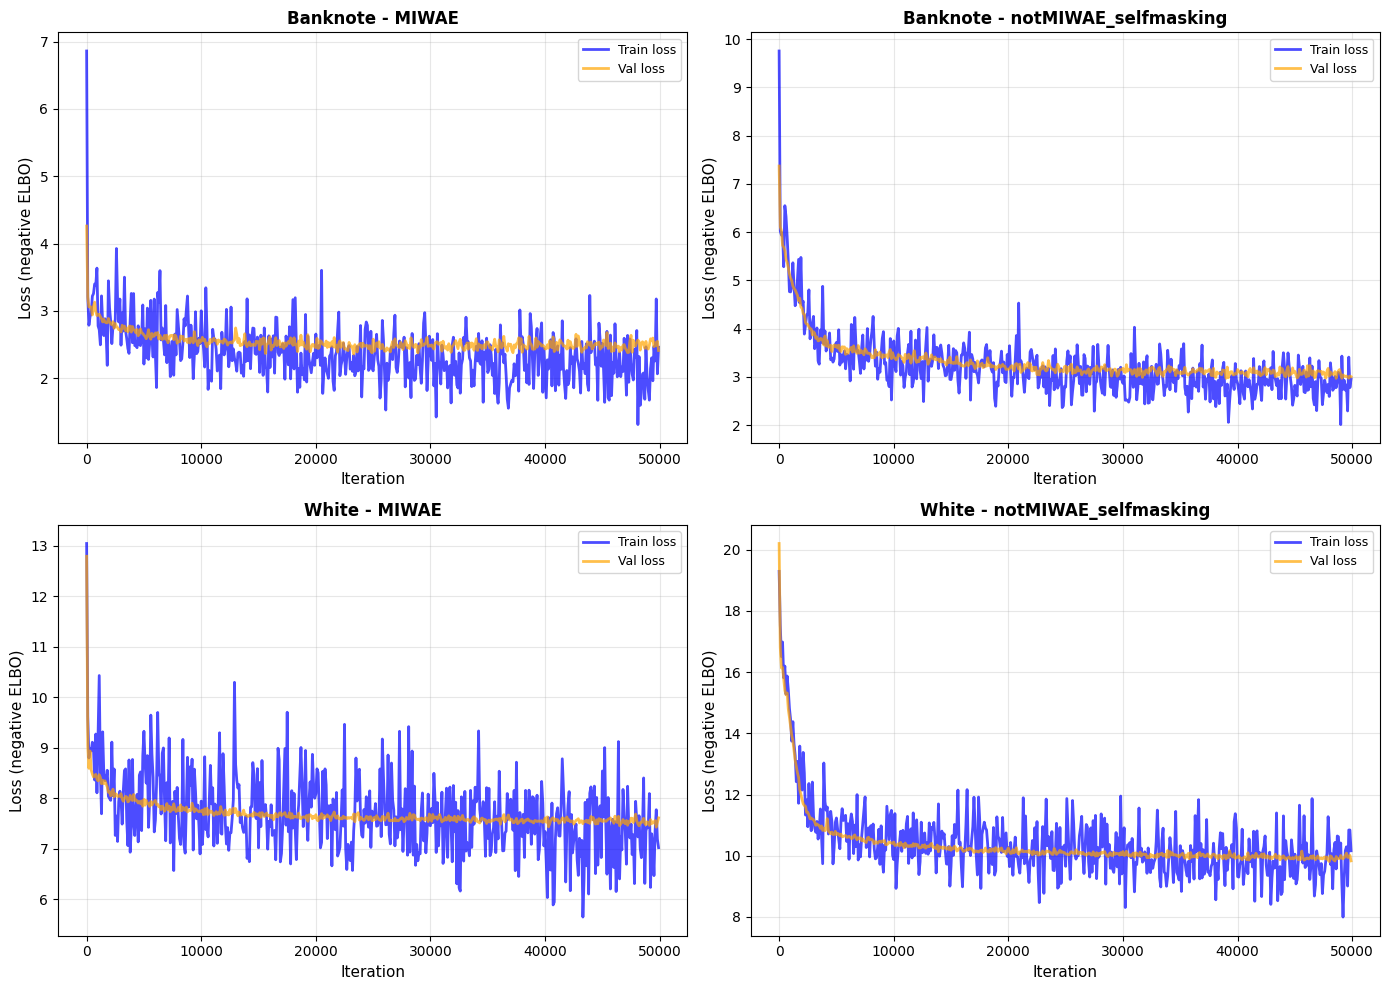


Plots generated successfully!

=== RMSE COMPARISON TABLE ===

 Dataset                Model  RMSE_train  RMSE_val       Gap
   White                MIWAE    1.555903  1.554173 -0.001729
   White notMIWAE_selfmasking    1.107368  1.118859  0.011490
Banknote                MIWAE    1.133853  1.160326  0.026473
Banknote notMIWAE_selfmasking    0.752205  0.729879 -0.022326


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create separate subplots for each model (independent y-axes)
datasets_used = list(set([key.split('_')[0] for key in loss_histories.keys()]))
n_datasets = len(datasets_used)
n_models = len(MODELS)

fig_loss, axes_loss = plt.subplots(n_datasets, n_models, figsize=(7*n_models, 5*n_datasets))

# Handle case where there's only one dataset or one model
if n_datasets == 1 and n_models == 1:
    axes_loss = np.array([[axes_loss]])
elif n_datasets == 1:
    axes_loss = axes_loss.reshape(1, -1)
elif n_models == 1:
    axes_loss = axes_loss.reshape(-1, 1)

for i, dataset in enumerate(datasets_used):
    for j, model_name in enumerate(MODELS):
        ax = axes_loss[i, j]
        key = f"{dataset}_{model_name}"

        if key in loss_histories:
            history = loss_histories[key]
            iterations = history['iterations']
            train_losses = history['train_losses']
            val_losses = history['val_losses']

            # Plot train and val losses
            ax.plot(iterations, train_losses, label='Train loss', linestyle='-', linewidth=2, color='blue', alpha=0.7)
            ax.plot(iterations, val_losses, label='Val loss', linestyle='-', linewidth=2, color='orange', alpha=0.7)

            ax.set_xlabel('Iteration', fontsize=11)
            ax.set_ylabel('Loss (negative ELBO)', fontsize=11)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)

        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12)

plt.tight_layout()
plt.show()

print("\nPlots generated successfully!")

# --- Display RMSE comparison table ---
print("\n=== RMSE COMPARISON TABLE ===")
print("\n" + df.to_string(index=False))

### Analysis

Evolution of train loss vs val loss show no overfitting but this is not the main overfitting to look for - what's most important is to compare imputation errors, e.g. RMSE of validation missing values.

Here the comparison of final RMSEs also show no overfitting, and a better performance of notMIWAE compared to MIWAE.

## More advanced missing mechanism

Here we want to stress-test notMIWAE with a more complex missing mechanism.

### First mask
The mask is defined by: $x \in X[:,j] \text{ missing } \Leftrightarrow x < d_{10}^j \text{ or } x > d_{90}^j$ with $d_{t}^j$ the $t^{th}$ decile of $X[:,j]$

In [4]:
def mask(X):
    return (X < np.percentile(X, 10)) | (X > np.percentile(X, 90))

In [7]:
# --- Paramètres de l'expérience ---

# Pour tester rapidement que tout marche, on réduit les itérations.
# Pour le VRAI résultat, mettez max_iter = 50000 ou 100000
MAX_ITER = 50000
BATCH_SIZE = 16
N_SAMPLES = 20
L_IMP = 500 # Échantillons pour l'imputation finale

# Validation split
VAL_SPLIT = 0.2  # 20% for validation

# Liste des datasets à tester (Commencez par 'White' pour tester)
DATASETS = ['White', 'Banknote']

# Liste des modèles
MODELS = ['MIWAE', 'notMIWAE_selfmasking']

results = []
loss_histories = {}  # Store loss histories for plotting

for dataset in DATASETS:
    # 1. Préparation Données
    data = load_uci_data(dataset)
    # On enlève la dernière colonne (target/class) comme dans task01.py
    data = data[:, :-1]

    N, D = data.shape
    dl = D - 1 # Dimension latente

    # Standardisation (Centrer-Réduire)
    scaler = StandardScaler()
    data = scaler.fit_transform(data)

    # Shuffle
    np.random.seed(42)
    p = np.random.permutation(N)
    data = data[p, :]

    # Train/Val split BEFORE introducing missing data
    data_train, data_val = train_test_split(data, test_size=VAL_SPLIT, random_state=42, shuffle=True)

    print(f"Dataset split: {len(data_train)} train, {len(data_val)} val")

    # Création des manques pour TRAIN
    Xnan_train, Xz_train = introduce_mnar_missing(data_train, , missing_mechanism=mask)
    S_train = np.array(~np.isnan(Xnan_train), dtype=np.float32)

    # Création des manques pour VAL (même mécanisme, mais patterns différents!)
    Xnan_val, Xz_val = introduce_mnar_missing(data_val, missing_mechanism=mask)
    S_val = np.array(~np.isnan(Xnan_val), dtype=np.float32)

    # 2. Entrainement des modèles
    for model_name in MODELS:
        tf.reset_default_graph() # Nettoyage mémoire TF
        sess_name = f"/tmp/{dataset}_{model_name}"

        print(f"\n--- Dataset: {dataset} | Modèle: {model_name} ---")

        if model_name == 'MIWAE':
            model = MIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                            n_hidden=128, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)

            # Calcul RMSE sur TRAIN (pour voir l'overfitting)
            rmse_train = utils.imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]

            # Calcul RMSE sur VAL (la vraie métrique de généralisation!)
            rmse_val = utils.imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        elif 'notMIWAE' in model_name:
            # Choix du processus (linear=agnostic, selfmasking, etc.)
            proc = 'linear' if 'agnostic' in model_name else 'selfmasking'
            if 'known' in model_name: proc = 'selfmasking_known'

            model = notMIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                                n_hidden=128, missing_process=proc, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)

            # Calcul RMSE sur TRAIN
            rmse_train = utils.not_imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]

            # Calcul RMSE sur VAL
            rmse_val = utils.not_imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        # Store loss history for plotting
        loss_histories[f"{dataset}_{model_name}"] = history

        print(f"\nRésultats RMSE:")
        print(f"  Train RMSE: {rmse_train:.4f} (données d'entraînement)")
        print(f"  Val RMSE:   {rmse_val:.4f} (données de validation - vraie métrique!)")
        print(f"  Generalization gap: {rmse_val - rmse_train:.4f}")

        # Store both metrics
        results.append({
            'Dataset': dataset,
            'Model': model_name,
            'RMSE_train': rmse_train,
            'RMSE_val': rmse_val,
            'Gap': rmse_val - rmse_train
        })

print("\n" + "="*80)
print("=== RÉSULTATS FINAUX ===")
print("="*80)
df = pd.DataFrame(results)
print("\nTableau complet:")
print(df.to_string(index=False))

print("\n" + "-"*80)
print("Interprétation:")
print("-"*80)
print("- RMSE_train: Performance sur les données d'entraînement (peut être biaisée)")
print("- RMSE_val:   Performance sur les données de validation (VRAIE métrique!)")
print("- Gap:        Différence = mesure de l'overfitting")
print("              Gap > 0 = normal (le modèle généralise moins bien)")
print("              Gap >> 0 = overfitting sévère")
print("="*80)


Chargement de White...
Dataset split: 3918 train, 980 val

--- Dataset: White | Modèle: MIWAE ---
Creating graph...
Saving session...
Saving session...
0/50000 updates, 3.47 s, 11.99 train_loss, 13.54 val_loss
Saving session...
100/50000 updates, 0.47 s, 9.59 train_loss, 11.93 val_loss
200/50000 updates, 0.38 s, 8.66 train_loss, 13.58 val_loss
300/50000 updates, 0.33 s, 8.86 train_loss, 14.40 val_loss
400/50000 updates, 0.34 s, 9.15 train_loss, 14.63 val_loss
500/50000 updates, 0.35 s, 9.68 train_loss, 14.67 val_loss
600/50000 updates, 0.34 s, 9.15 train_loss, 15.33 val_loss
700/50000 updates, 0.34 s, 8.60 train_loss, 14.93 val_loss
800/50000 updates, 0.37 s, 9.70 train_loss, 14.93 val_loss
900/50000 updates, 0.34 s, 8.02 train_loss, 15.88 val_loss
1000/50000 updates, 0.34 s, 8.94 train_loss, 15.31 val_loss
1100/50000 updates, 0.37 s, 10.11 train_loss, 14.74 val_loss
1200/50000 updates, 0.34 s, 8.71 train_loss, 15.12 val_loss
1300/50000 updates, 0.33 s, 8.09 train_loss, 14.04 val_loss


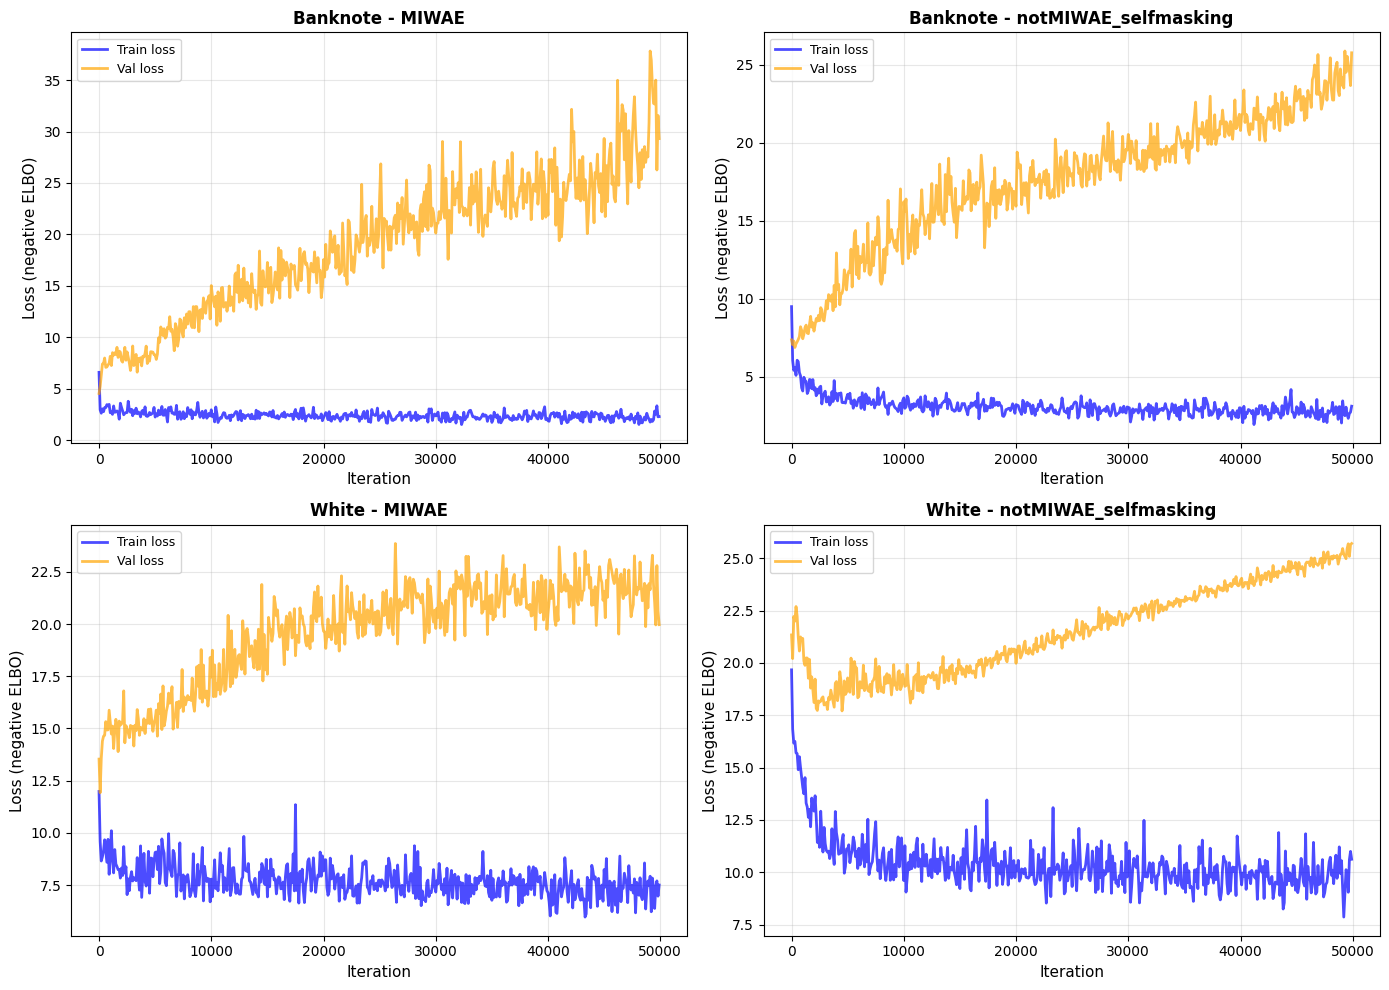


Plots generated successfully!

=== RMSE COMPARISON TABLE ===

 Dataset                Model  RMSE_train  RMSE_val      Gap
   White                MIWAE    1.544665  2.036150 0.491485
   White notMIWAE_selfmasking    1.090167  1.753716 0.663548
Banknote                MIWAE    1.226240  1.359313 0.133073
Banknote notMIWAE_selfmasking    1.210074  1.698470 0.488396


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Create separate subplots for each model (independent y-axes)
datasets_used = list(set([key.split('_')[0] for key in loss_histories.keys()]))
n_datasets = len(datasets_used)
n_models = len(MODELS)

fig_loss, axes_loss = plt.subplots(n_datasets, n_models, figsize=(7*n_models, 5*n_datasets))

# Handle case where there's only one dataset or one model
if n_datasets == 1 and n_models == 1:
    axes_loss = np.array([[axes_loss]])
elif n_datasets == 1:
    axes_loss = axes_loss.reshape(1, -1)
elif n_models == 1:
    axes_loss = axes_loss.reshape(-1, 1)

for i, dataset in enumerate(datasets_used):
    for j, model_name in enumerate(MODELS):
        ax = axes_loss[i, j]
        key = f"{dataset}_{model_name}"

        if key in loss_histories:
            history = loss_histories[key]
            iterations = history['iterations']
            train_losses = history['train_losses']
            val_losses = history['val_losses']

            # Plot train and val losses
            ax.plot(iterations, train_losses, label='Train loss', linestyle='-', linewidth=2, color='blue', alpha=0.7)
            ax.plot(iterations, val_losses, label='Val loss', linestyle='-', linewidth=2, color='orange', alpha=0.7)

            ax.set_xlabel('Iteration', fontsize=11)
            ax.set_ylabel('Loss (negative ELBO)', fontsize=11)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)

        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12)

plt.tight_layout()
plt.show()

print("\nPlots generated successfully!")

# --- Display RMSE comparison table ---
print("\n=== RMSE COMPARISON TABLE ===")
print("\n" + df.to_string(index=False))

## Probabilistic missing mechanism